In [26]:
import optuna
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
study = optuna.load_study(
    storage=r"sqlite:///../../results/exploratory/1000_optuna/optuna.sqlite3",
    study_name="resnet50_64img_1pilse_1sample_0.5delay",
)

SCALE = 8

In [28]:
df = study.trials_dataframe()
df = df[df.state == "COMPLETE"]
df.to_csv("../../results/exploratory/1000_optuna/data.csv")

In [29]:
df_failed = df[df.value == 0.825]
df_unchanged = df[df.value == 0.6875]
df_one = df[df.value == 0.671875]
df_success = df[df.value < 0.4]

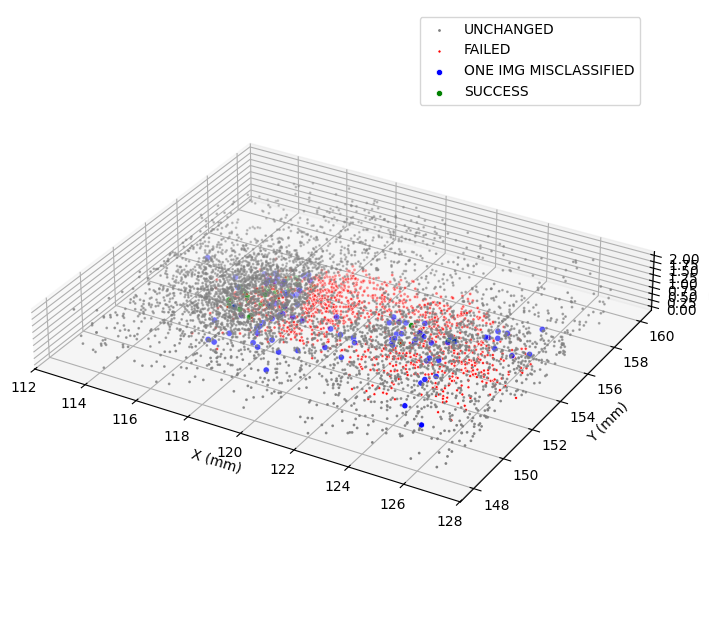

In [30]:
fig = plt.figure(figsize=(SCALE,SCALE))
ax = fig.add_subplot(111, projection="3d")

x_range = df["params_x"].max() - df["params_x"].min()
y_range = df["params_y"].max() - df["params_y"].min()
z_range = df["params_z"].max() - df["params_z"].min()

ax.set_box_aspect((x_range, y_range, z_range))

ax.scatter(
    df_unchanged["params_x"],
    df_unchanged["params_y"],
    df_unchanged["params_z"],
    c="gray",
    s=1,
    label="UNCHANGED",
)

ax.scatter(
    df_failed["params_x"],
    df_failed["params_y"],
    df_failed["params_z"],
    c="red",
    s=5,
    edgecolor="w",
    linewidth=0.5,
    label="FAILED",
)

ax.scatter(
    df_one["params_x"],
    df_one["params_y"],
    df_one["params_z"],
    c="blue",
    s=20,
    edgecolor="w",
    linewidth=0.5,
    label="ONE IMG MISCLASSIFIED",
)

ax.scatter(
    df_success["params_x"],
    df_success["params_y"],
    df_success["params_z"],
    c="green",
    s=20,
    edgecolor="w",
    linewidth=0.5,
    label="SUCCESS",
)

ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")
ax.legend()

plt.savefig("../../results/exploratory/1000_optuna/3d.svg")

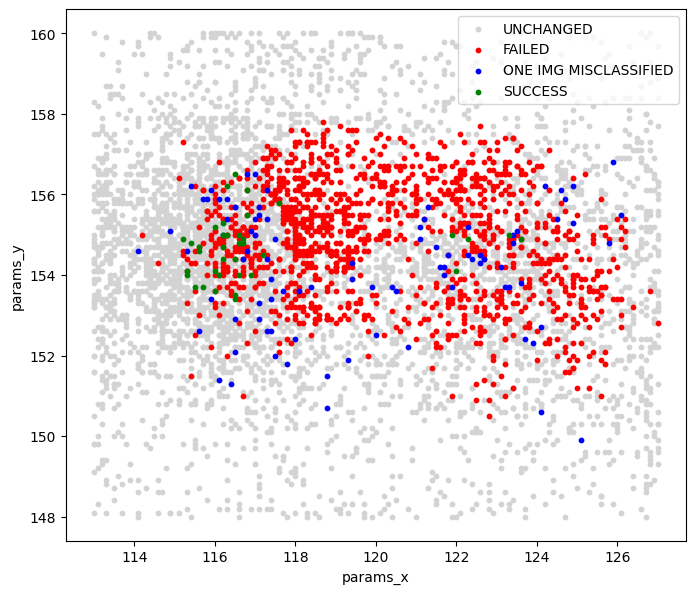

In [31]:
fig, ax = plt.subplots(figsize=(SCALE, SCALE))

ax.set_aspect("equal")

param_x = "params_x"
param_y = "params_y"

ax.scatter(
    df_unchanged[param_x],
    df_unchanged[param_y],
    c="lightgray",
    label="UNCHANGED",
    s=10,
)
ax.scatter(
    df_failed[param_x],
    df_failed[param_y],
    c="red",
    label="FAILED",
    s=10,
)
ax.scatter(
    df_one[param_x],
    df_one[param_y],
    c="blue",
    label="ONE IMG MISCLASSIFIED",
    s=10,
)
ax.scatter(
    df_success[param_x],
    df_success[param_y],
    c="green",
    label="SUCCESS",
    s=10,
)

ax.set_xlabel(param_x)
ax.set_ylabel(param_y)
ax.legend()

plt.savefig("../../results/exploratory/1000_optuna/2d.svg")

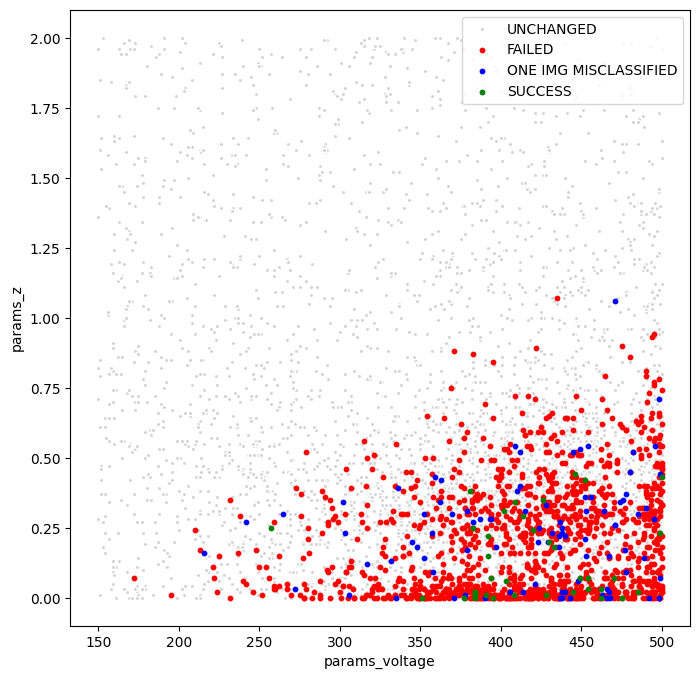

In [32]:
fig, ax = plt.subplots(figsize=(SCALE, SCALE))

# ax.set_aspect("equal")

param_x = "params_voltage"
param_y = "params_z"

ax.scatter(
    df_unchanged[param_x],
    df_unchanged[param_y],
    c="lightgray",
    linewidths=1,
    edgecolors="white",
    label="UNCHANGED",
    s=10,
)
ax.scatter(
    df_failed[param_x],
    df_failed[param_y],
    c="red",
    # linewidths=1,
    # edgecolors="w",
    label="FAILED",
    s=10,
)
ax.scatter(
    df_one[param_x],
    df_one[param_y],
    c="blue",
    # linewidths=1,
    # edgecolors="w",
    label="ONE IMG MISCLASSIFIED",
    s=10,
)
ax.scatter(
    df_success[param_x],
    df_success[param_y],
    c="green",
    # linewidths=1,
    # edgecolors="w",
    label="SUCCESS",
    s=10,
)

ax.set_xlabel(param_x)
ax.set_ylabel(param_y)
ax.legend()

plt.savefig("../../results/exploratory/1000_optuna/z_vs_voltage.svg")

In [33]:
df.describe()

,number,value,datetime_start,datetime_complete,duration,params_voltage,params_width,params_x,params_y,params_z
count,5749.000000,5749.000000,5749,5749,5749,5749.000000,5749.000000,5749.000000,5749.000000,5749.000000
mean,2874.584971,0.712284,2026-04-05 07:00:27.791125,2026-04-05 07:00:40.007878,0 days 00:00:12.216753,378.898417,1.571230,119.142390,154.398261,0.477422
min,0.000000,0.000000,2026-04-04 18:42:20.290487,2026-04-04 18:42:28.466015,0 days 00:00:04.843010,150.000000,1.000000,113.000000,148.000000,0.000000
25%,1437.000000,0.687500,2026-04-04 22:19:08.829744,2026-04-04 22:19:16.649837,0 days 00:00:06.758138,329.000000,1.000000,116.000000,153.000000,0.110000
50%,2874.000000,0.687500,2026-04-05 03:55:33.265211,2026-04-05 03:55:39.982111,0 days 00:00:07.068579,397.000000,1.000000,118.200000,154.500000,0.330000
75%,4312.000000,0.687500,2026-04-05 15:31:42.968481,2026-04-05 15:32:16.989593,0 days 00:00:07.738831,444.000000,2.000000,122.400000,155.900000,0.630000
max,5750.000000,0.825000,2026-04-05 21:04:55.626125,2026-04-05 21:05:29.741750,0 days 00:01:43.410444,500.000000,3.000000,127.000000,160.000000,2.000000
std,1660.353239,0.080120,NaN,NaN,0 days 00:00:10.973485,86.982042,0.735103,3.806786,2.330279,0.479273
